In [2]:
import glob
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from scipy.stats import kstest, mannwhitneyu, ranksums, ttest_ind
from statsmodels.stats.multitest import fdrcorrection, multipletests

%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

from sklearn.impute import SimpleImputer

ERROR! Session/line number was not unique in database. History logging moved to new session 115


In [82]:
# original methylation beta value for single trend CpG
from statannotations.Annotator import Annotator

know_ALS_gene_beta_temp = temp_.loc[
    temp_cpg_list_all.apply(lambda x: x[0] + "_" + str(x[1]), axis=1).values
]

know_ALS_gene_beta_temp = pd.DataFrame(
    StandardScaler()
    .fit_transform(SimpleImputer().fit_transform(know_ALS_gene_beta_temp.T))
    .T,
    columns=know_ALS_gene_beta_temp.columns,
    index=know_ALS_gene_beta_temp.index,
)
know_ALS_gene_beta_temp.insert(0, "Gene", temp_cpg_list_all["annot.symbol"].values)
#know_ALS_gene_beta_temp["Gene"] = temp_cpg_list_all["annot.symbol"].values
know_ALS_gene_beta_temp.to_csv(
    "./Fig.3.Zscore.csv",
    index=True,
)

/tmp/chaoronc/48232642/ipykernel_3587552/4273649470.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  temp_cpg_list_all.apply(lambda x: x[0] + "_" + str(x[1]), axis=1).values


In [ ]:
know_ALS_gene_beta_temp = pd.read_csv(
    "./Fig.3.Zscore.csv", index_col=0
)  # , header=0, index_col=0)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ATXN2_Control vs. ATXN2_sALS: Mann-Whitney-Wilcoxon test two-sided, P_val:1.541e-02 U_stat=2.870e+02
TARDBP_Control vs. TARDBP_sALS: Mann-Whitney-Wilcoxon test two-sided, P_val:9.126e-03 U_stat=2.960e+02
C9orf72_Control vs. C9orf72_C9-Carrier: Mann-Whitney-Wilcoxon test two-sided, P_val:6.768e-03 U_stat=4.050e+01
ATXN2_Control vs. ATXN2_C9ALS: Mann-Whitney-Wilcoxon test two-sided, P_val:3.857e-03 U_stat=1.730e+02
TARDBP_Control vs. TARDBP_C9ALS: Mann-Whitney-Wilcoxon test two-sided, P_val:1.877e-03 U_stat=1.790e+02
C9orf72_Control vs. C9orf72_C9ALS: Mann-Whitney-Wilcoxon test two-sided, P_val:5.938e-03 U_stat=3.950e+01


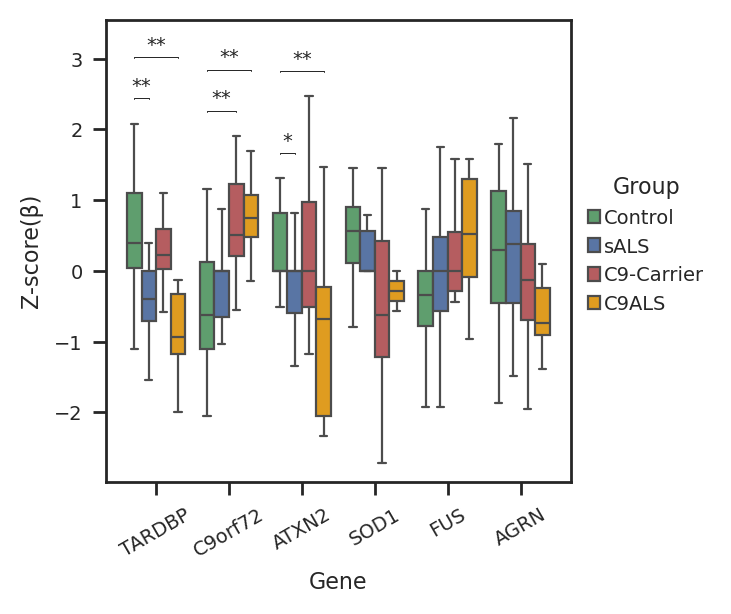

In [84]:
know_ALS_gene_beta_temp = know_ALS_gene_beta_temp[
    know_ALS_gene_beta_temp.iloc[:, 1:].var(axis=1) != 0
]
know_ALS_gene_beta_temp_melt = know_ALS_gene_beta_temp.melt(
    id_vars=["Gene"], ignore_index=False, var_name="Group", value_name="z"
).dropna()  # .sort_values(by='gene')
know_ALS_gene_beta_temp_melt["Group"] = (
    know_ALS_gene_beta_temp_melt["Group"]
    .apply(lambda x: x.split("_")[0])
    .replace("C9-Patient", "C9ALS")
)


# beta
color_map = {"Control": "g", "C9-Carrier": "r", "C9ALS": "orange", "sALS": "b"}

mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

f, ax = plt.subplots(figsize=(3, 3))
sns.boxplot(
    know_ALS_gene_beta_temp_melt,
    linewidth=0.8,
    x="Gene",
    hue="Group",
    y="z",
    ax=ax,
    showmeans=False,
    width=0.8,
    dodge=True,
    palette=color_map,
    showfliers=False,
    order=["TARDBP", "C9orf72", "ATXN2", "SOD1", "FUS", "AGRN"],
)


x = "Gene"
y = "z"
hue = "Group"
hue_order = ["Control", "sALS", "C9-Carrier", "C9ALS"]
order = ["TARDBP", "C9orf72", "ATXN2", "SOD1", "FUS", "AGRN"]
pairs = [
    (("TARDBP", "Control"), ("TARDBP", "sALS")),
    (("TARDBP", "Control"), ("TARDBP", "C9ALS")),
    (("C9orf72", "Control"), ("C9orf72", "C9-Carrier")),
    (("C9orf72", "Control"), ("C9orf72", "C9ALS")),
    (("ATXN2", "Control"), ("ATXN2", "sALS")),
    (("ATXN2", "Control"), ("ATXN2", "C9ALS")),
]
annot = Annotator(
    ax,
    pairs,
    data=know_ALS_gene_beta_temp_melt,
    x=x,
    y=y,
    order=order,
    hue=hue,
    hue_order=hue_order,
)
# annot.new_plot(ax, pairs, data=df, x=x, y=y, order=order, hue=hue, hue_order=hue_order)
annot.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    color="black",
    line_width=0.3,
    fontsize=7,
    hide_non_significant=True,
    line_height=0.003,
)

annot.apply_test()
annot.annotate()


ax.legend(
    bbox_to_anchor=(1, 0.7),
    frameon=False,
    handlelength=0.6,
    handletextpad=0.2,
    title="Group",
    title_fontsize=8,
    fontsize=7,
)
ax.set(ylabel="Z-score(β)")  # , title='Known ALS genes associated CpGs')
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="both", labelsize=7)
ax.set_xlabel("Gene", fontsize=8)
ax.set_ylabel("Z-score(β)", fontsize=8)
ax.figure.savefig(
    "./Fig.3.png",
    bbox_inches="tight",
    dpi=600,
)